# Intrusion Detection using CIC-IDS2017

This notebook presents a machine learning pipeline for network intrusion detection using the CIC-IDS2017 MachineLearningCSV dataset. The task is formulated as a supervised binary classification problem, where each network flow is classified as either benign traffic or malicious traffic.

The notebook includes dataset loading, exploratory data analysis with visualisation of the class distribution, preprocessing, a comparison of two candidate models, systematic hyperparameter tuning of the selected model using cross-validation, final model evaluation, model saving, and model loading for reproducibility.

# Notes for Marker

To check the final trained model directly, please first run the 1st and 3rd cells that import the required libraries and define the project paths.

The trained model is saved in the `models/` folder. The processed datasets used for validation and final testing are stored in the `data/processed/` folder. To control the submission file size, these processed datasets have been compressed as `.zip` files:

* `train_set_binary_balanced.zip`
* `validation_set_binary.zip`
* `test_set_binary.zip`

Before running the final model loading and testing section, please unzip these three files and keep the extracted files inside the same `data/processed/` folder. After this, the notebook section for loading the saved model and reproducing the final test results can be run directly.

The reported results were produced using the recommended Python environment for this module. Small numerical differences may occur if different library versions are used, especially for model loading, metric calculation, or randomised operations.

The raw CICIDS2017 CSV files are not included in this repository/submission folder because of file size. If you want to reproduce the full training process from the original raw data, please download the CICIDS2017 MachineLearningCSV files from the official dataset website and place them in the `data/raw/` folder before running the notebook from the beginning:

https://www.unb.ca/cic/datasets/ids-2017.html


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import matplotlib.pyplot as plt
import joblib

In [2]:
def clean_label(label):
    """
    Clean label names for consistent display.
    This mainly fixes corrupted Web Attack labels caused by encoding issues.
    """
    label = str(label).strip()
    
    # Replace common corrupted or special dash characters with a normal hyphen.
    label = label.replace("�", "-")
    label = label.replace("—", "-")
    label = label.replace("â€“", "-")
    label = label.replace("\xa0", " ")
    
    # Normalise repeated spaces.
    label = " ".join(label.split())
    
    # Standardise Web Attack labels.
    if label.startswith("Web Attack") and "Brute Force" in label:
        return "Web Attack - Brute Force"
    if label.startswith("Web Attack") and "XSS" in label:
        return "Web Attack - XSS"
    if label.startswith("Web Attack") and "Sql Injection" in label:
        return "Web Attack - Sql Injection"
    
    return label

In [3]:
PROJECT_ROOT = Path(".")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

for directory in [PROCESSED_DIR, MODEL_DIR, RESULTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Data directory:", DATA_DIR.resolve())
print("Processed directory:", PROCESSED_DIR.resolve())
print("Model directory:", MODEL_DIR.resolve())
print("Results directory:", RESULTS_DIR.resolve())

Project root: /home/aics/ai-labs/Assessment
Data directory: /home/aics/ai-labs/Assessment/data/raw
Processed directory: /home/aics/ai-labs/Assessment/data/processed
Model directory: /home/aics/ai-labs/Assessment/models
Results directory: /home/aics/ai-labs/Assessment/results


## 1. Dataset

The dataset used in this project is the CIC-IDS2017 MachineLearningCSV dataset. The CSV files contain flow-based network traffic features extracted from PCAP files using CICFlowMeter. Each row represents one network flow, and the original label identifies whether the flow is benign or belongs to a specific attack category.

All eight CSV files in the MachineLearningCSV folder are loaded in this notebook. The original multi-class attack labels are later converted into a binary target variable:

- BENIGN = 0
- Any attack type = 1

In [4]:
csv_files = sorted(DATA_DIR.glob("*.csv"))

print("Number of CSV files:", len(csv_files))
for file in csv_files:
    print(file.name)

Number of CSV files: 8
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


## 2. Exploratory Data Analysis

Before building the models, the label distribution of each CSV file is inspected. This is important because CIC-IDS2017 contains multiple attack types and the class distribution is highly imbalanced. Understanding this distribution helps justify the problem formulation and the evaluation strategy.

The overall class distribution is also visualised on a logarithmic scale, because the class sizes span several orders of magnitude, from over two million benign flows down to only eleven Heartbleed flows.

In [5]:
label_summary_records = []

for file in csv_files:
    print("=" * 100)
    print(file.name)
    
    df_temp = pd.read_csv(file, low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()
    
    if "Label" not in df_temp.columns:
        raise ValueError(f"No Label column found in {file.name}")
    
    df_temp["Label_clean"] = df_temp["Label"].apply(clean_label)
    
    print("Shape:", df_temp.shape)
    
    label_counts = df_temp["Label_clean"].value_counts()
    print(label_counts)
    
    for label, count in label_counts.items():
        label_summary_records.append({
            "file": file.name,
            "label": label,
            "count": count
        })

label_summary = pd.DataFrame(label_summary_records)

label_summary_pivot = label_summary.pivot_table(
    index="file",
    columns="label",
    values="count",
    fill_value=0,
    aggfunc="sum"
)

label_summary_pivot

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Shape: (225745, 80)
Label_clean
DDoS      128027
BENIGN     97718
Name: count, dtype: int64
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Shape: (286467, 80)
Label_clean
PortScan    158930
BENIGN      127537
Name: count, dtype: int64
Friday-WorkingHours-Morning.pcap_ISCX.csv
Shape: (191033, 80)
Label_clean
BENIGN    189067
Bot         1966
Name: count, dtype: int64
Monday-WorkingHours.pcap_ISCX.csv
Shape: (529918, 80)
Label_clean
BENIGN    529918
Name: count, dtype: int64
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Shape: (288602, 80)
Label_clean
BENIGN          288566
Infiltration        36
Name: count, dtype: int64
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Shape: (170366, 80)
Label_clean
BENIGN                        168186
Web Attack - Brute Force        1507
Web Attack - XSS                 652
Web Attack - Sql Injection        21
Name: count, dtype: int64
Tuesday-WorkingHours.pcap_ISCX.csv
Shape: 

label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack - Brute Force,Web Attack - Sql Injection,Web Attack - XSS
file,,,,,,,,,,,,,,,
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,97718,0,128027,0,0,0,0,0,0,0,0,0,0,0,0
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,127537,0,0,0,0,0,0,0,0,0,158930,0,0,0,0
Friday-WorkingHours-Morning.pcap_ISCX.csv,189067,1966,0,0,0,0,0,0,0,0,0,0,0,0,0
Monday-WorkingHours.pcap_ISCX.csv,529918,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,288566,0,0,0,0,0,0,0,0,36,0,0,0,0,0
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,168186,0,0,0,0,0,0,0,0,0,0,0,1507,21,652
Tuesday-WorkingHours.pcap_ISCX.csv,432074,0,0,0,0,0,0,7938,0,0,0,5897,0,0,0
Wednesday-workingHours.pcap_ISCX.csv,440031,0,0,10293,231073,5499,5796,0,11,0,0,0,0,0,0


In [6]:
total_label_counts = label_summary.groupby("label")["count"].sum().sort_values(ascending=False)
total_label_counts

label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

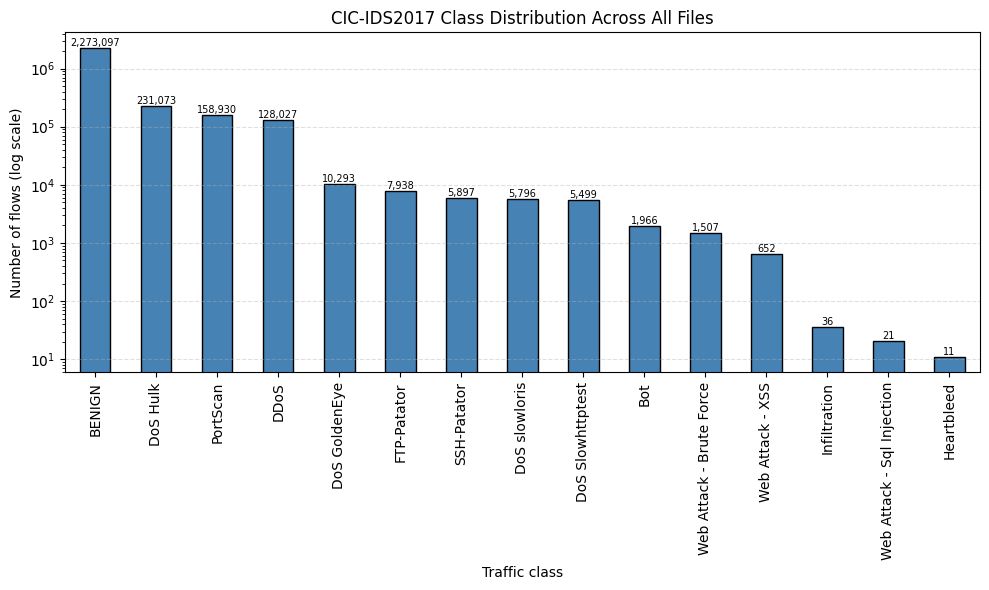

In [7]:
# --- EDA Figure 1: multi-class label distribution (log scale) ---
fig, ax = plt.subplots(figsize=(10, 6))

total_label_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")

ax.set_yscale("log")
ax.set_ylabel("Number of flows (log scale)")
ax.set_xlabel("Traffic class")
ax.set_title("CIC-IDS2017 Class Distribution Across All Files")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Annotate each bar with its exact count.
for i, v in enumerate(total_label_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_class_distribution.png", dpi=300)
plt.show()

In [8]:
label_summary_pivot.to_csv(RESULTS_DIR / "label_distribution_by_file.csv")
total_label_counts.to_csv(RESULTS_DIR / "total_label_distribution.csv")

print("Label distribution files saved.")

Label distribution files saved.


## 3. Problem Formulation

This project formulates intrusion detection as a binary classification problem: distinguishing benign network traffic from malicious traffic. Binary intrusion detection is a fundamental task in cyber security because a deployed intrusion detection system first needs to recognise whether a flow is suspicious before investigating the specific attack category.

A binary task is also more suitable for this coursework than multi-class attack classification because several attack classes in the dataset are extremely small, such as Heartbleed, SQL Injection, and Infiltration. Training a multi-class model directly on these rare categories would likely produce unreliable class-level results.

The target variable is therefore defined as:

- `0`: BENIGN traffic
- `1`: Malicious traffic, including all attack types

In [9]:
target_mapping = {
    "BENIGN": 0,
    "All attack labels": 1
}

target_mapping

{'BENIGN': 0, 'All attack labels': 1}

## 4. Data Loading

All eight CSV files are loaded and combined into one dataframe. The source file name is temporarily stored so that the origin of each row can be traced during analysis. Column names are stripped to remove leading or trailing whitespace, which is a common issue in this dataset.

In [10]:
dfs = []

for file in csv_files:
    print(f"Loading: {file.name}")
    
    df = pd.read_csv(file, low_memory=False)
    df.columns = df.columns.str.strip()
    df["source_file"] = file.name
    
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data["Label_clean"] = data["Label"].apply(clean_label)

print("Combined dataset shape:", data.shape)
data.head()

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Combined dataset shape: (2830743, 81)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file,Label_clean
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,BENIGN


In [11]:
print("Columns:")
for col in data.columns:
    print(col)

Columns:
Destination Port
Flow Duration
Total Fwd Packets
Total Backward Packets
Total Length of Fwd Packets
Total Length of Bwd Packets
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min
Fwd PSH Flags
Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
Fwd Header Length
Bwd Header Length
Fwd Packets/s
Bwd Packets/s
Min Packet Length
Max Packet Length
Packet Length Mean
Packet Length Std
Packet Length Variance
FIN Flag Count
SYN Flag Count
RST Flag Count
PSH Flag Count
ACK Flag Count
URG Flag Count
CWE Flag Count
ECE Flag Count
Down/Up Ratio
Average Packet Size
Avg Fwd Segment Size
Avg Bwd Segment Size
Fwd Header Length.1
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd Av

In [12]:
print("Original label distribution:")
print(data["Label_clean"].value_counts())

data["target_binary"] = data["Label_clean"].apply(
    lambda x: 0 if str(x).strip() == "BENIGN" else 1
)

print("\nBinary target distribution:")
print(data["target_binary"].value_counts())

print("\nBinary target distribution as proportion:")
print(data["target_binary"].value_counts(normalize=True))

Original label distribution:
Label_clean
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Binary target distribution:
target_binary
0    2273097
1     557646
Name: count, dtype: int64

Binary target distribution as proportion:
target_binary
0    0.803004
1    0.196996
Name: proportion, dtype: float64


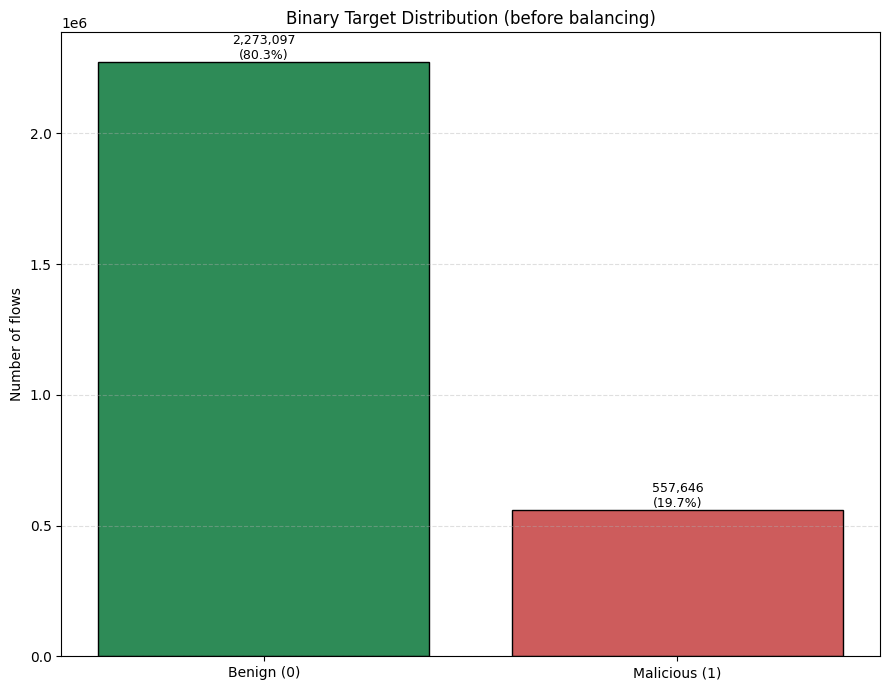

In [13]:
# --- EDA Figure 2: binary target distribution ---
binary_counts = data["target_binary"].value_counts().sort_index()
binary_labels = ["Benign (0)", "Malicious (1)"]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.bar(binary_labels, binary_counts.values,
              color=["seagreen", "indianred"], edgecolor="black")

ax.set_ylabel("Number of flows")
ax.set_title("Binary Target Distribution (before balancing)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

total = binary_counts.sum()
for bar, v in zip(bars, binary_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v,
            f"{v:,}\n({v / total:.1%})", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_binary_distribution.png", dpi=300)
plt.show()

## 5. Data Preprocessing

Several preprocessing steps are applied before training:

1. Infinite values are replaced with missing values.
2. Duplicate rows are removed.
3. The original multi-class label is converted into a binary target.
4. Non-numeric or leakage-prone columns are removed.
5. Remaining columns are converted to numeric values.

The columns `Label`, `Label_clean`, `target_binary`, and `source_file` are removed because they may introduce data leakage. For example, a model might learn that a particular IP address or time period is associated with an attack rather than learning generalisable network traffic behaviour.

In [14]:
# Replace infinite values with NaN.
data = data.replace([np.inf, -np.inf], np.nan)

# Remove duplicate rows.
rows_before = data.shape[0]
data = data.drop_duplicates()
rows_after = data.shape[0]

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Duplicates removed:", rows_before - rows_after)

Rows before removing duplicates: 2830743
Rows after removing duplicates: 2574264
Duplicates removed: 256479


In [ ]:
drop_cols = [
    "Label",
    "Label_clean",
    "target_binary",
    "source_file"
]

drop_cols = [col for col in drop_cols if col in data.columns]

X = data.drop(columns=drop_cols)
y = data["target_binary"]

# Convert all remaining features to numeric values.
X = X.apply(pd.to_numeric, errors="coerce")

# Remove columns that are entirely missing, if any.
all_missing_cols = X.columns[X.isna().all()].tolist()

if all_missing_cols:
    print("Dropping all-missing columns:", all_missing_cols)
    X = X.drop(columns=all_missing_cols)
else:
    print("No all-missing columns found.")

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Total missing values in X:", X.isna().sum().sum())

No all-missing columns found.
Feature matrix shape: (2574264, 78)
Target shape: (2574264,)
Total missing values in X: 3248


In [16]:
missing_summary = X.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

print("Number of columns with missing values:", len(missing_summary))
missing_summary.head(20)

Number of columns with missing values: 2


Flow Packets/s    1624
Flow Bytes/s      1624
dtype: int64

## 6. Train, Validation, and Test Split

The dataset is split into three parts:

- 70% training set
- 15% validation set
- 15% test set

Stratified splitting is used to preserve the benign/malicious class ratio in each split. The validation set is used to compare the two candidate models and select which one to take forward. Hyperparameter tuning of the selected model is then performed using cross-validation on the training data. The test set is held out and used only for the final evaluation, so that it provides an independent estimate of performance.

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print(y_train.value_counts(normalize=True))

print("\nValidation set:", X_val.shape)
print(y_val.value_counts(normalize=True))

print("\nTest set:", X_test.shape)
print(y_test.value_counts(normalize=True))

Training set: (1801984, 78)
target_binary
0    0.834563
1    0.165437
Name: proportion, dtype: float64

Validation set: (386140, 78)
target_binary
0    0.834563
1    0.165437
Name: proportion, dtype: float64

Test set: (386140, 78)
target_binary
0    0.834563
1    0.165437
Name: proportion, dtype: float64


## 7. Handling Class Imbalance

The dataset is imbalanced, with benign traffic forming the majority class. To reduce this imbalance during training, a balanced training subset is created by undersampling benign traffic to match the number of malicious samples.

This balancing is applied only to the training set. The validation and test sets are kept in their original distribution so that model evaluation remains closer to the real class distribution in the dataset.

In [18]:
train_df = X_train.copy()
train_df["target_binary"] = y_train.values

benign_train = train_df[train_df["target_binary"] == 0]
malicious_train = train_df[train_df["target_binary"] == 1]

print("Original benign training samples:", len(benign_train))
print("Original malicious training samples:", len(malicious_train))

Original benign training samples: 1503870
Original malicious training samples: 298114


In [19]:
n_malicious = len(malicious_train)

benign_sample = benign_train.sample(
    n=n_malicious,
    random_state=42
)

balanced_train = pd.concat(
    [benign_sample, malicious_train],
    axis=0
).sample(frac=1, random_state=42)

X_train_balanced = balanced_train.drop(columns=["target_binary"])
y_train_balanced = balanced_train["target_binary"]

print("Balanced training set shape:", X_train_balanced.shape)
print(y_train_balanced.value_counts())
print(y_train_balanced.value_counts(normalize=True))

Balanced training set shape: (596228, 78)
target_binary
0    298114
1    298114
Name: count, dtype: int64
target_binary
0    0.5
1    0.5
Name: proportion, dtype: float64


## 8. Model Selection

Two machine learning models are compared:

1. Logistic Regression
2. Random Forest

Logistic Regression is used as a simple and interpretable baseline model. It is useful for assessing whether a linear decision boundary can separate benign and malicious traffic.

Random Forest is used as a stronger non-linear model. It is suitable for tabular network flow data because it can capture non-linear relationships and interactions between features such as flow duration, packet length statistics, byte rates, and flag counts.

The two models are first trained with reasonable default settings and compared on the validation set. The stronger model is then taken forward for systematic hyperparameter tuning in Section 9.1.

In [20]:
logistic_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

random_forest_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

## 9. Model Training and Validation

Both models are trained on the balanced training subset. They are then evaluated on the validation set, which keeps the original class distribution.

The following metrics are used:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In intrusion detection, recall is important because false negatives correspond to malicious flows that are missed by the model. Precision is also important because excessive false positives can overwhelm analysts and reduce trust in the system.

In [21]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

validation_results = []

for name, model in models.items():
    print("=" * 100)
    print(f"Training {name}")
    
    model.fit(X_train_balanced, y_train_balanced)
    
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    roc_auc = roc_auc_score(y_val, y_val_proba)
    
    validation_results.append({
        "model": name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    })
    
    print(classification_report(
        y_val,
        y_val_pred,
        target_names=["Benign", "Malicious"]
    ))

validation_results_df = pd.DataFrame(validation_results)
validation_results_df

Training Logistic Regression
              precision    recall  f1-score   support

      Benign       0.99      0.93      0.96    322258
   Malicious       0.73      0.98      0.84     63882

    accuracy                           0.94    386140
   macro avg       0.86      0.95      0.90    386140
weighted avg       0.95      0.94      0.94    386140

Training Random Forest
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    322258
   Malicious       0.99      1.00      1.00     63882

    accuracy                           1.00    386140
   macro avg       1.00      1.00      1.00    386140
weighted avg       1.00      1.00      1.00    386140



,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.937243,0.733183,0.975752,0.837252,0.986765
1,Random Forest,0.998690,0.994029,0.998075,0.996048,0.999951


In [22]:
validation_results_df.to_csv(
    RESULTS_DIR / "validation_results.csv",
    index=False
)

validation_results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.937243,0.733183,0.975752,0.837252,0.986765
1,Random Forest,0.998690,0.994029,0.998075,0.996048,0.999951


## 9.1 Hyperparameter Tuning of the Random Forest

Random Forest was selected as the candidate model based on the validation comparison above. Its hyperparameters are now tuned using `GridSearchCV` with 2-fold stratified cross-validation on the balanced training set, optimising the macro F1-score so that performance on the minority malicious class is weighted equally with the majority benign class.

Given the size of the balanced training set and the memory constraints of the available compute environment, the search space was kept deliberately focused. The grid varies the maximum tree depth (`max_depth`) and the minimum number of samples per leaf (`min_samples_leaf`), which are the two parameters that most directly control the bias-variance trade-off and the degree of regularisation in each tree. The number of estimators was fixed at 100, as preliminary results showed that additional trees produced negligible gains at substantially higher computational cost. The best configuration identified by cross-validation is then used as the final model.

In [23]:
rf_tuning_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1               
    ))
])

param_grid = {
    "classifier__n_estimators": [100],
    "classifier__max_depth": [20, 30],
    "classifier__min_samples_leaf": [1, 5]
}

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=2,                       
    n_jobs=1,                    
    verbose=2,
    refit=True
)

grid_search.fit(X_train_balanced, y_train_balanced)

print("Best cross-validation macro F1:", grid_search.best_score_)
print("Best parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END classifier__max_depth=20, classifier__min_samples_leaf=1, classifier__n_estimators=100; total time=  26.4s
[CV] END classifier__max_depth=20, classifier__min_samples_leaf=1, classifier__n_estimators=100; total time=  24.6s
[CV] END classifier__max_depth=20, classifier__min_samples_leaf=5, classifier__n_estimators=100; total time=  24.6s
[CV] END classifier__max_depth=20, classifier__min_samples_leaf=5, classifier__n_estimators=100; total time=  24.9s
[CV] END classifier__max_depth=30, classifier__min_samples_leaf=1, classifier__n_estimators=100; total time=  24.5s
[CV] END classifier__max_depth=30, classifier__min_samples_leaf=1, classifier__n_estimators=100; total time=  24.7s
[CV] END classifier__max_depth=30, classifier__min_samples_leaf=5, classifier__n_estimators=100; total time=  24.7s
[CV] END classifier__max_depth=30, classifier__min_samples_leaf=5, classifier__n_estimators=100; total time=  23.9s
Best cross-va

In [24]:
# Save the full grid search results as evidence of the tuning process.
cv_results_df = pd.DataFrame(grid_search.cv_results_)

cv_results_summary = cv_results_df[[
    "param_classifier__n_estimators",
    "param_classifier__max_depth",
    "param_classifier__min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

cv_results_summary.to_csv(
    RESULTS_DIR / "random_forest_gridsearch_results.csv",
    index=False
)

cv_results_summary

,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
0,100,20,1,0.998720,0.000005,1
2,100,30,1,0.998491,0.000013,2
3,100,30,5,0.998356,0.000023,3
1,100,20,5,0.998329,0.000030,4


## 10. Final Model Selection

Random Forest is selected as the final model. The validation comparison in Section 9 showed that Random Forest clearly outperformed Logistic Regression, particularly in malicious precision and F1-score. Logistic Regression achieved high malicious recall but lower precision, indicating a higher false positive rate, whereas Random Forest provided a better balance between detecting malicious traffic and avoiding false alarms.

The hyperparameter search in Section 9.1 then identified the best Random Forest configuration using cross-validation. The differences between the configurations were very small, which suggests that the model is not strongly sensitive to these hyperparameters on this dataset. The best estimator returned by the grid search, already refitted on the full balanced training set, is used as the final model below.

In [25]:
# The final model is the best estimator found by GridSearchCV,
final_model = grid_search.best_estimator_

print("Final model selected from grid search:")
print(final_model.named_steps["classifier"])

Final model selected from grid search:
RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       n_jobs=-1, random_state=42)


## 11. Final Evaluation on the Test Set

The selected Random Forest model is evaluated on the test set. The test set was not used during training or model selection, so it provides the final estimate of model performance in this experiment.

In [26]:
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

test_results = pd.DataFrame([{
    "model": "Random Forest",
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
    "roc_auc": test_roc_auc
}])

test_results

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.99885,0.994142,0.998936,0.996533,0.99996


In [27]:
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Benign", "Malicious"]
))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    322258
   Malicious       0.99      1.00      1.00     63882

    accuracy                           1.00    386140
   macro avg       1.00      1.00      1.00    386140
weighted avg       1.00      1.00      1.00    386140



In [28]:
test_results.to_csv(
    RESULTS_DIR / "test_results.csv",
    index=False
)

test_classification_report = classification_report(
    y_test,
    y_test_pred,
    target_names=["Benign", "Malicious"],
    output_dict=True
)

test_classification_report_df = pd.DataFrame(test_classification_report).transpose()

test_classification_report_df.to_csv(
    RESULTS_DIR / "classification_report_random_forest_test.csv"
)

test_classification_report_df

,precision,recall,f1-score,support
Benign,0.999789,0.998833,0.999311,322258.00000
Malicious,0.994142,0.998936,0.996533,63882.00000
accuracy,0.998850,0.998850,0.998850,0.99885
macro avg,0.996966,0.998884,0.997922,386140.00000
weighted avg,0.998855,0.998850,0.998851,386140.00000


## 12. Confusion Matrix

The confusion matrix is used to inspect the number of correct and incorrect predictions for each class. In binary intrusion detection, the most important error type is often the false negative: malicious traffic predicted as benign.

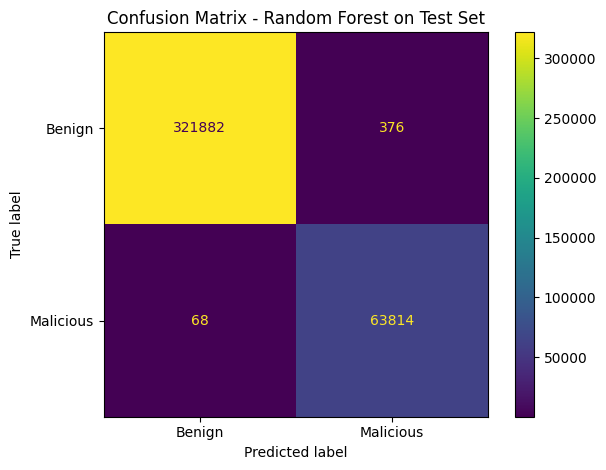

array([[321882,    376],
       [    68,  63814]])

In [29]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malicious"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - Random Forest on Test Set")
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "confusion_matrix_random_forest_test.png",
    dpi=300
)

plt.show()

cm

## 13. Feature Importance

Random Forest provides feature importance scores, which can help interpret which flow-based features contributed most to the model's predictions. These importance values should be interpreted cautiously because they show association within this dataset rather than causal explanations.

In [30]:
rf_classifier = final_model.named_steps["classifier"]

feature_importance_df = pd.DataFrame({
    "feature": X_train_balanced.columns,
    "importance": rf_classifier.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_df.to_csv(
    RESULTS_DIR / "random_forest_feature_importance.csv",
    index=False
)

feature_importance_df.head(20)

,feature,importance
39,Max Packet Length,0.085215
41,Packet Length Std,0.073308
52,Average Packet Size,0.062662
42,Packet Length Variance,0.057888
54,Avg Bwd Segment Size,0.055413
10,Bwd Packet Length Max,0.043844
13,Bwd Packet Length Std,0.038452
0,Destination Port,0.038100
67,Init_Win_bytes_backward,0.026988
66,Init_Win_bytes_forward,0.025934


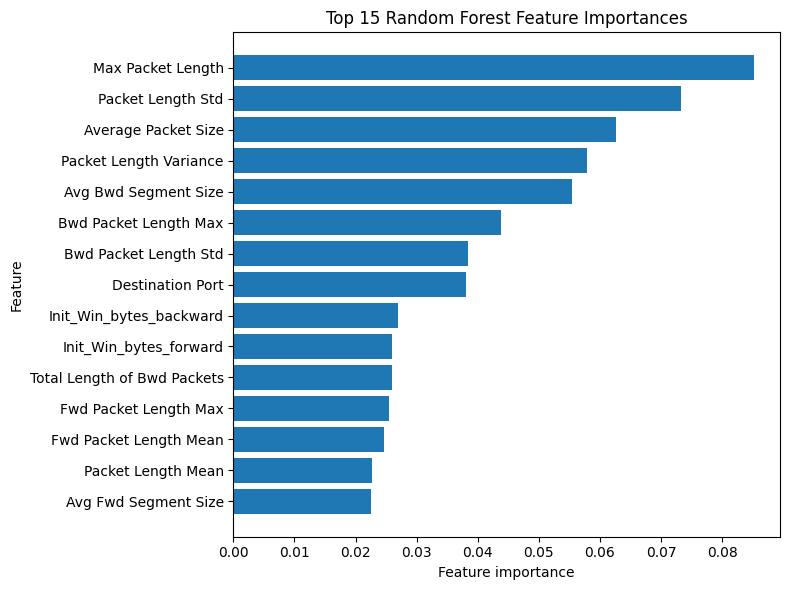

In [31]:
top_features = feature_importance_df.head(15).sort_values(by="importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "random_forest_top_15_feature_importance.png",
    dpi=300
)

plt.show()

## 14. Saving the Model and Processed Data

The final Random Forest model is saved using joblib. The processed training, validation, and test sets are also saved so that the reported results can be reproduced without re-running the full preprocessing pipeline from the raw CSV files.

In [32]:
final_model_path = MODEL_DIR / "random_forest_binary_cicids2017.joblib"

joblib.dump(final_model, final_model_path)

print("Final model saved to:", final_model_path)

Final model saved to: models/random_forest_binary_cicids2017.joblib


In [33]:
train_set = X_train_balanced.copy()
train_set["target_binary"] = y_train_balanced.values

validation_set = X_val.copy()
validation_set["target_binary"] = y_val.values

test_set = X_test.copy()
test_set["target_binary"] = y_test.values

train_set.to_csv(PROCESSED_DIR / "train_set_binary_balanced.csv", index=False)
validation_set.to_csv(PROCESSED_DIR / "validation_set_binary.csv", index=False)
test_set.to_csv(PROCESSED_DIR / "test_set_binary.csv", index=False)

print("Processed datasets saved:")
print(PROCESSED_DIR / "train_set_binary_balanced.csv")
print(PROCESSED_DIR / "validation_set_binary.csv")
print(PROCESSED_DIR / "test_set_binary.csv")

Processed datasets saved:
data/processed/train_set_binary_balanced.csv
data/processed/validation_set_binary.csv
data/processed/test_set_binary.csv


## 15. Model Loading and Reproducibility Check

This section demonstrates that the saved model can be loaded and used to reproduce the test results. This is important because the submitted coursework should include not only the trained model but also the code required to load it and run the reported tests.

In [34]:
loaded_model = joblib.load(MODEL_DIR / "random_forest_binary_cicids2017.joblib")

loaded_test_set = pd.read_csv(PROCESSED_DIR / "test_set_binary.csv")

X_loaded_test = loaded_test_set.drop(columns=["target_binary"])
y_loaded_test = loaded_test_set["target_binary"]

loaded_predictions = loaded_model.predict(X_loaded_test)

print(classification_report(
    y_loaded_test,
    loaded_predictions,
    target_names=["Benign", "Malicious"]
))

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    322258
   Malicious       0.99      1.00      1.00     63882

    accuracy                           1.00    386140
   macro avg       1.00      1.00      1.00    386140
weighted avg       1.00      1.00      1.00    386140



In [35]:
loaded_accuracy = accuracy_score(y_loaded_test, loaded_predictions)
loaded_precision = precision_score(y_loaded_test, loaded_predictions)
loaded_recall = recall_score(y_loaded_test, loaded_predictions)
loaded_f1 = f1_score(y_loaded_test, loaded_predictions)

reproducibility_results = pd.DataFrame([{
    "loaded_model_accuracy": loaded_accuracy,
    "loaded_model_precision": loaded_precision,
    "loaded_model_recall": loaded_recall,
    "loaded_model_f1": loaded_f1
}])

reproducibility_results.to_csv(
    RESULTS_DIR / "loaded_model_reproducibility_results.csv",
    index=False
)

reproducibility_results

,loaded_model_accuracy,loaded_model_precision,loaded_model_recall,loaded_model_f1
0,0.99885,0.994142,0.998936,0.996533


## 16. Reflection and Limitations

The Random Forest model achieved very high performance on the test set. However, this result should be interpreted carefully. CIC-IDS2017 is a structured benchmark dataset with flow-based features and labelled traffic, so performance on this dataset may be higher than performance in a real operational network.

The hyperparameter search also suggested that the model is largely insensitive to the tuned parameters, and the best configuration used the least restrictive leaf setting. Together with the near-perfect scores, this points to the dataset being highly separable rather than to the model having learned a difficult decision boundary.

Another limitation is the use of a random train-validation-test split. Although the test set was not used for training or model selection, random splitting can still produce optimistic results if similar traffic patterns from the same attack scenario appear across all splits. A stricter future evaluation could use a time-based split, where earlier days are used for training and later days are used for testing.

The current project also focuses on binary classification. This is useful for detecting whether traffic is malicious, but it does not identify the exact attack type. Future work could extend the task to multi-class classification, although this would require careful handling of rare attack classes such as Heartbleed, SQL Injection, and Infiltration.

Further improvements could include a wider hyperparameter search, feature selection, decision threshold adjustment, and evaluation on additional intrusion detection datasets to assess cross-dataset generalisation.

## 17. Output Files

This notebook produces the following outputs:

- `results/label_distribution_by_file.csv`
- `results/total_label_distribution.csv`
- `results/eda_class_distribution.png`
- `results/eda_binary_distribution.png`
- `results/validation_results.csv`
- `results/random_forest_gridsearch_results.csv`
- `results/test_results.csv`
- `results/classification_report_random_forest_test.csv`
- `results/confusion_matrix_random_forest_test.png`
- `results/random_forest_feature_importance.csv`
- `results/random_forest_top_15_feature_importance.png`
- `results/loaded_model_reproducibility_results.csv`
- `models/random_forest_binary_cicids2017.joblib`
- `data/processed/train_set_binary_balanced.csv`
- `data/processed/validation_set_binary.csv`
- `data/processed/test_set_binary.csv`

These files support reproducibility and provide evidence for the results discussed in the report.